# Strategic Classification: No-Poisoning Baseline

Runs RGD and PerfGD on the credit dataset across all valid (classifier, performativity) combinations.

**Classifiers:** LogReg, MLP

**Performativity models:**
- **Linear:** `x'_S = x_S - alpha * theta_S` (logreg only)
- **Matrix:** `x'_S = x_S - alpha * A @ theta_S` (logreg only)
- **Elementwise:** `x'_S = x_S - alpha * g(theta_S)` (logreg only, default g=tanh)
- **Gradient:** `x'_S = x_S - alpha * grad_x_S P(y=1|x)` (any classifier)

In [161]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

cwd = os.getcwd()  # poison-perf/strategic/
root = os.path.dirname(cwd)  # poison-perf/
sys.path.append(root)

from utils.algorithms import RGD, PerfGD
from strategic.strategic_setup import setup_strategic_classification, _mlp_forward
from utils.data_prep import load_data

## Load Data

In [162]:
data_dir = "data/GiveMeSomeCredit"
data_file = "cs-training.csv"
data_path = os.path.join(root, data_dir, data_file)
X_np, Y_np, data = load_data(data_path)

n_samples, d_plus_bias = X_np.shape
print("n_samples =", n_samples, ", d+1 (with bias) =", d_plus_bias)

strat_features = np.array([1, 6, 8]) - 1  # 0-indexed
print("\nStrategic features:")
for i, feature in enumerate(strat_features):
    print(f"  {i}: [{feature}] {data.columns[feature + 1]}")

device = torch.device("cpu")
X_full = torch.from_numpy(X_np).float().to(device)
Y_full = torch.from_numpy(Y_np).float().to(device)

lam = 1.0 / n_samples
alpha_strat = 1.0

n_samples = 18357 , d+1 (with bias) = 11

Strategic features:
  0: [0] RevolvingUtilizationOfUnsecuredLines
  1: [5] NumberOfOpenCreditLinesAndLoans
  2: [7] NumberRealEstateLoansOrLines


## Hyperparameters and Experiment Definitions

In [163]:
n = n_samples
max_iter = 100

# Smoothness-based learning rate (for logreg)
smoothness = (X_full ** 2).sum().item() / (4.0 * n_samples)
eta_logreg = 2.0 / (smoothness + 2.0 * lam)
eta_mlp = 0.2  # MLP needs smaller, fixed learning rate

proj_theta = lambda t: t

# Response matrix for "matrix" performativity: diagonal with per-feature manipulation costs
# RevolvingUtilization (easy), OpenCreditLines (moderate), RealEstateLoans (hard)
A_matrix = torch.diag(torch.tensor([1.5, 1.0, 0.5], dtype=torch.float32))

MLP_HIDDEN_DIMS = [32, 16]

experiments = [
    {"name": "LogReg + Linear",       "classifier": "logreg", "performativity": "linear",      "eta": eta_logreg},
    {"name": "LogReg + Matrix",        "classifier": "logreg", "performativity": "matrix",      "eta": eta_logreg, "response_matrix": A_matrix},
    {"name": "LogReg + Elementwise",   "classifier": "logreg", "performativity": "elementwise", "eta": eta_logreg},
    {"name": "LogReg + Gradient",      "classifier": "logreg", "performativity": "gradient",    "eta": eta_logreg},
    {"name": "MLP + Gradient",         "classifier": "mlp",    "performativity": "gradient",    "eta": eta_mlp, "hidden_dims": MLP_HIDDEN_DIMS},
    {"name": "LogReg + Noisy Grad (0.1)", "classifier": "logreg", "performativity": "gradient", "eta": eta_logreg, "noise_std": 0.1},
    {"name": "LogReg + Noisy Grad (0.5)", "classifier": "logreg", "performativity": "gradient", "eta": eta_logreg, "noise_std": 0.5},
    {"name": "MLP + Noisy Grad (0.1)",    "classifier": "mlp",    "performativity": "gradient", "eta": eta_mlp, "hidden_dims": MLP_HIDDEN_DIMS, "noise_std": 0.1},
    {"name": "MLP + Noisy Grad (0.5)",    "classifier": "mlp",    "performativity": "gradient", "eta": eta_mlp, "hidden_dims": MLP_HIDDEN_DIMS, "noise_std": 0.5},
]

print(f"eta_logreg = {eta_logreg:.4f}, eta_mlp = {eta_mlp}")
print(f"A_matrix =\n{A_matrix}")
print(f"\nExperiments ({len(experiments)}):")
for e in experiments:
    print(f"  {e['name']}")

eta_logreg = 0.4286, eta_mlp = 0.2
A_matrix =
tensor([[1.5000, 0.0000, 0.0000],
        [0.0000, 1.0000, 0.0000],
        [0.0000, 0.0000, 0.5000]])

Experiments (9):
  LogReg + Linear
  LogReg + Matrix
  LogReg + Elementwise
  LogReg + Gradient
  MLP + Gradient
  LogReg + Noisy Grad (0.1)
  LogReg + Noisy Grad (0.5)
  MLP + Noisy Grad (0.1)
  MLP + Noisy Grad (0.5)


## Run All Experiments (RGD + PerfGD)

In [164]:
def compute_accuracy(theta, D_theta, classifier, hidden_dims, d, n):
    """Compute classification accuracy on strategically-shifted data."""
    z = D_theta(theta, n)
    with torch.no_grad():
        x = z[:-1, :]  # (d, n)
        y = z[-1, :]    # (n,)
        
        if classifier == "logreg":
            logits = theta[:-1] @ x + theta[-1]
        elif classifier == "mlp":
            logits = _mlp_forward(x.T, theta, d, hidden_dims)
        
        preds = (logits > 0).float()
        return (preds == y).float().mean().item()

results = {}

for exp in experiments:
    name = exp["name"]
    eta = exp["eta"]
    clf = exp["classifier"]
    hdims = exp.get("hidden_dims", MLP_HIDDEN_DIMS)
    print(f"\n{'='*60}")
    print(f"Running: {name} (eta={eta:.4f})")
    print(f"{'='*60}")

    # Build setup kwargs (exclude name and eta)
    setup_kwargs = {
        "X_base": X_full,
        "Y_base": Y_full,
        "strat_features": strat_features.tolist(),
        "alpha": alpha_strat,
        "lam": lam,
        "perfGD": True,
        "classifier": clf,
        "performativity": exp["performativity"],
    }
    if "hidden_dims" in exp:
        setup_kwargs["hidden_dims"] = hdims
    if "response_matrix" in exp:
        setup_kwargs["response_matrix"] = exp["response_matrix"]
    if "noise_std" in exp:
        setup_kwargs["noise_std"] = exp["noise_std"]

    mu_f, sigma, D_theta, loss_fn, theta_0, grad2_est, f_hat = \
        setup_strategic_classification(**setup_kwargs)

    print(f"  theta_0: {theta_0.shape} ({theta_0.numel()} params)")

    d = X_full.shape[1] - 1  # feature dim without bias

    # RGD
    print("  Running RGD...", end=" ")
    theta_rgd, all_theta_rgd, all_losses_rgd = RGD(
        D_theta=D_theta, loss=loss_fn, theta_0=theta_0.clone(),
        n=n, eta=eta, max_iter=max_iter, proj_theta=proj_theta, return_losses=True,
    )
    print(f"final loss = {all_losses_rgd[-1]:.4f}")

    # PerfGD
    print("  Running PerfGD...", end=" ")
    theta_perfgd, all_theta_perfgd, all_losses_perfgd = PerfGD(
        f_hat=f_hat, grad2_est=grad2_est, D_theta=D_theta, loss=loss_fn,
        theta_0=theta_0.clone(), n=n, eta=eta, max_iter=max_iter,
        proj_theta=proj_theta, return_losses=True,
    )
    print(f"final loss = {all_losses_perfgd[-1]:.4f}")

    # Compute accuracy at each iteration
    print("  Computing accuracies...", end=" ")
    rgd_accs = [compute_accuracy(t, D_theta, clf, hdims, d, n) for t in all_theta_rgd]
    perfgd_accs = [compute_accuracy(t, D_theta, clf, hdims, d, n) for t in all_theta_perfgd]
    print(f"RGD final acc = {rgd_accs[-1]:.4f}, PerfGD final acc = {perfgd_accs[-1]:.4f}")

    theta_0_stored = theta_0.detach().clone()
    results[name] = {
        "theta_0": theta_0_stored,
        "classifier": clf,
        "rgd_losses": all_losses_rgd,
        "perfgd_losses": all_losses_perfgd,
        "rgd_theta": theta_rgd.detach(),
        "perfgd_theta": theta_perfgd.detach(),
        "all_theta_rgd": [t.detach().clone() for t in all_theta_rgd],
        "all_theta_perfgd": [t.detach().clone() for t in all_theta_perfgd],
        "rgd_theta_diffs": [(t - theta_0_stored).norm().item() for t in all_theta_rgd],
        "perfgd_theta_diffs": [(t - theta_0_stored).norm().item() for t in all_theta_perfgd],
        "rgd_accs": rgd_accs,
        "perfgd_accs": perfgd_accs,
    }

print("\nDone.")


Running: LogReg + Linear (eta=0.4286)
  theta_0: torch.Size([11]) (11 params)
  Running RGD... final loss = 0.6194
  Running PerfGD... final loss = 0.6238
  Computing accuracies... RGD final acc = 0.7037, PerfGD final acc = 0.6995

Running: LogReg + Matrix (eta=0.4286)
  theta_0: torch.Size([11]) (11 params)
  Running RGD... final loss = 0.6192
  Running PerfGD... final loss = 0.6233
  Computing accuracies... RGD final acc = 0.7051, PerfGD final acc = 0.7062

Running: LogReg + Elementwise (eta=0.4286)
  theta_0: torch.Size([11]) (11 params)
  Running RGD... final loss = 0.6194
  Running PerfGD... final loss = 0.6236
  Computing accuracies... RGD final acc = 0.7037, PerfGD final acc = 0.7003

Running: LogReg + Gradient (eta=0.4286)
  theta_0: torch.Size([11]) (11 params)
  Running RGD... final loss = 0.6194
  Running PerfGD... final loss = 0.6169
  Computing accuracies... RGD final acc = 0.7051, PerfGD final acc = 0.7105

Running: MLP + Gradient (eta=0.2000)
  theta_0: torch.Size([897]

## RGD Loss Curves

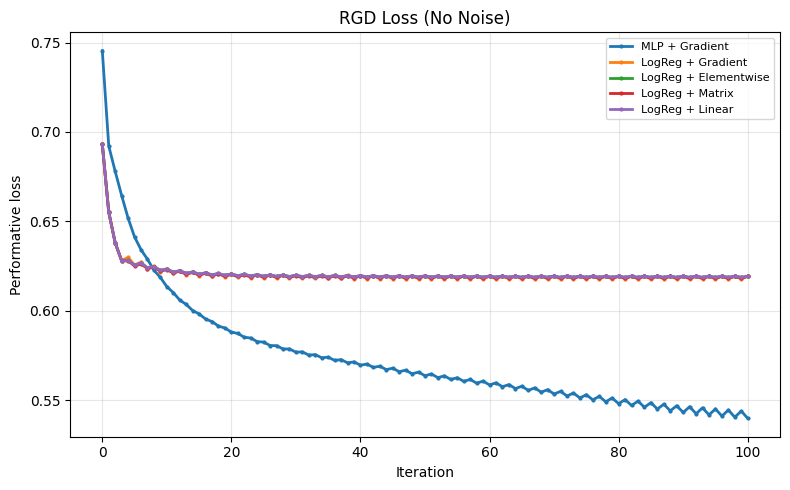

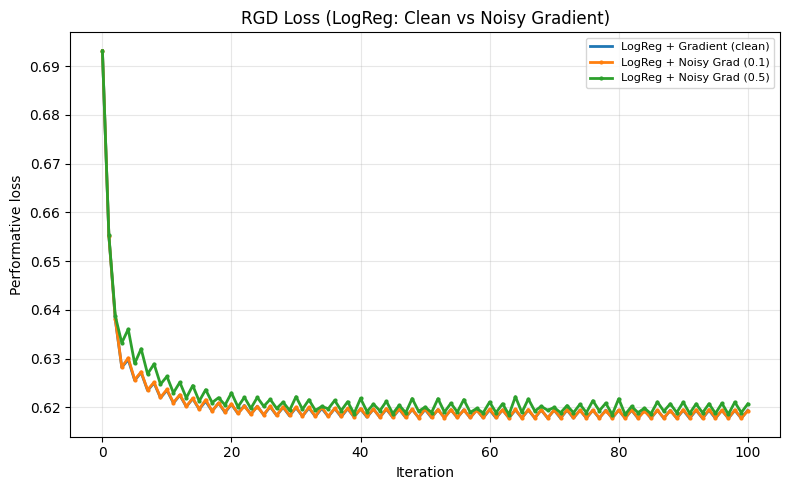

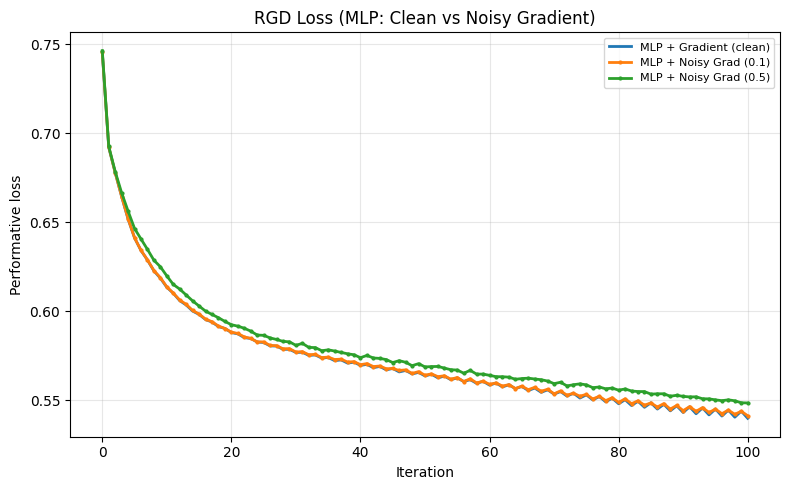

In [165]:
# --- RGD Loss: All no-noise experiments ---
no_noise = {k: v for k, v in results.items() if "Noisy" not in k}
logreg_noisy = {k: v for k, v in results.items() if "LogReg" in k and "Noisy" in k}
mlp_noisy = {k: v for k, v in results.items() if "MLP" in k and "Noisy" in k}

fig, ax = plt.subplots(figsize=(8, 5))
for name, res in reversed(list(no_noise.items())):
    ax.plot(res["rgd_losses"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"Performative loss")
ax.set_title(r"RGD Loss (No Noise)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- RGD Loss: LogReg clean gradient vs noisy ---
fig, ax = plt.subplots(figsize=(8, 5))
if "LogReg + Gradient" in results:
    ax.plot(results["LogReg + Gradient"]["rgd_losses"], linewidth=2, label="LogReg + Gradient (clean)")
for name, res in logreg_noisy.items():
    ax.plot(res["rgd_losses"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"Performative loss")
ax.set_title(r"RGD Loss (LogReg: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- RGD Loss: MLP clean gradient vs noisy ---
fig, ax = plt.subplots(figsize=(8, 5))
if "MLP + Gradient" in results:
    ax.plot(results["MLP + Gradient"]["rgd_losses"], linewidth=2, label="MLP + Gradient (clean)")
for name, res in mlp_noisy.items():
    ax.plot(res["rgd_losses"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"Performative loss")
ax.set_title(r"RGD Loss (MLP: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

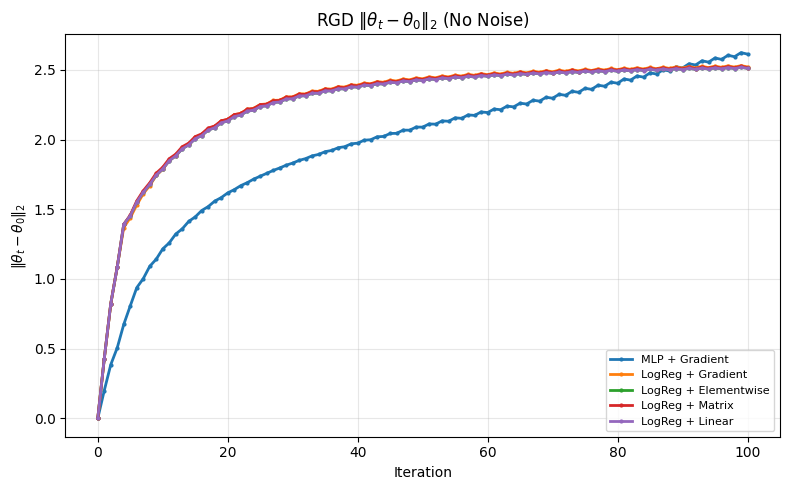

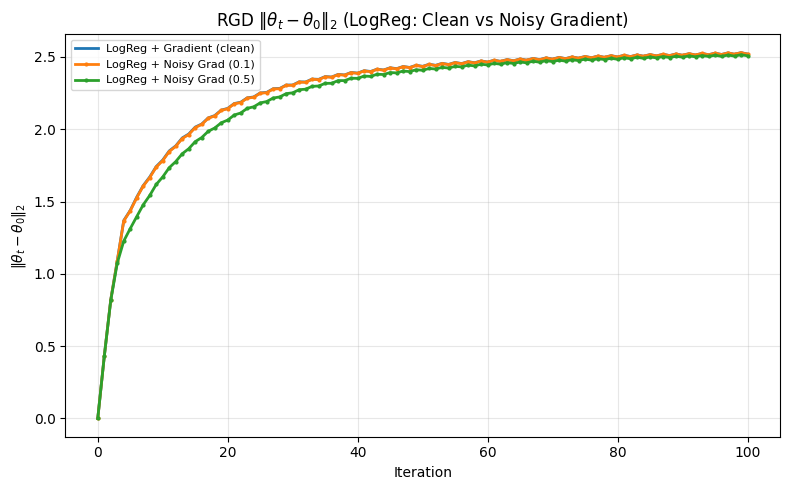

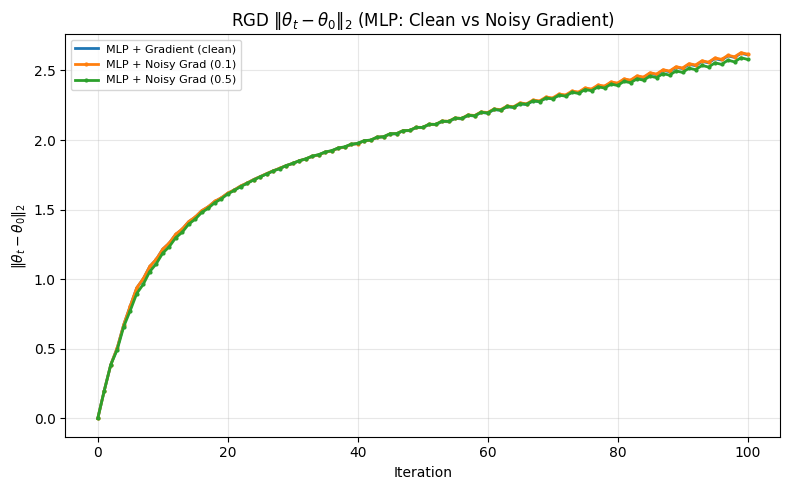

In [166]:
# --- RGD $\|\theta_t - \theta_0\|_2$: All no-noise experiments ---
no_noise = {k: v for k, v in results.items() if "Noisy" not in k}
logreg_noisy = {k: v for k, v in results.items() if "LogReg" in k and "Noisy" in k}
mlp_noisy = {k: v for k, v in results.items() if "MLP" in k and "Noisy" in k}

fig, ax = plt.subplots(figsize=(8, 5))
for name, res in reversed(list(no_noise.items())):
    ax.plot(res["rgd_theta_diffs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
ax.set_title(r"RGD $\|\theta_t - \theta_0\|_2$ (No Noise)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- RGD $\|\theta_t - \theta_0\|_2$: LogReg clean gradient vs noisy ---
fig, ax = plt.subplots(figsize=(8, 5))
if "LogReg + Gradient" in results:
    ax.plot(results["LogReg + Gradient"]["rgd_theta_diffs"], linewidth=2, label="LogReg + Gradient (clean)")
for name, res in logreg_noisy.items():
    ax.plot(res["rgd_theta_diffs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
ax.set_title(r"RGD $\|\theta_t - \theta_0\|_2$ (LogReg: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- RGD $\|\theta_t - \theta_0\|_2$: MLP clean gradient vs noisy ---
fig, ax = plt.subplots(figsize=(8, 5))
if "MLP + Gradient" in results:
    ax.plot(results["MLP + Gradient"]["rgd_theta_diffs"], linewidth=2, label="MLP + Gradient (clean)")
for name, res in mlp_noisy.items():
    ax.plot(res["rgd_theta_diffs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
ax.set_title(r"RGD $\|\theta_t - \theta_0\|_2$ (MLP: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PerfGD Loss Curves

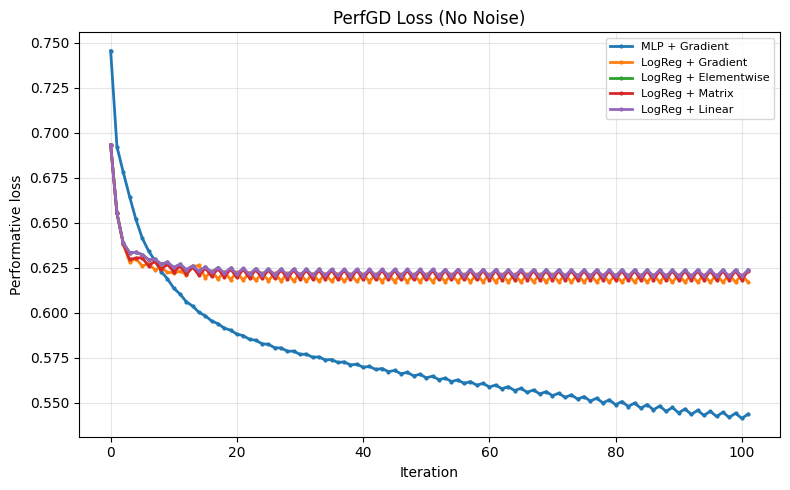

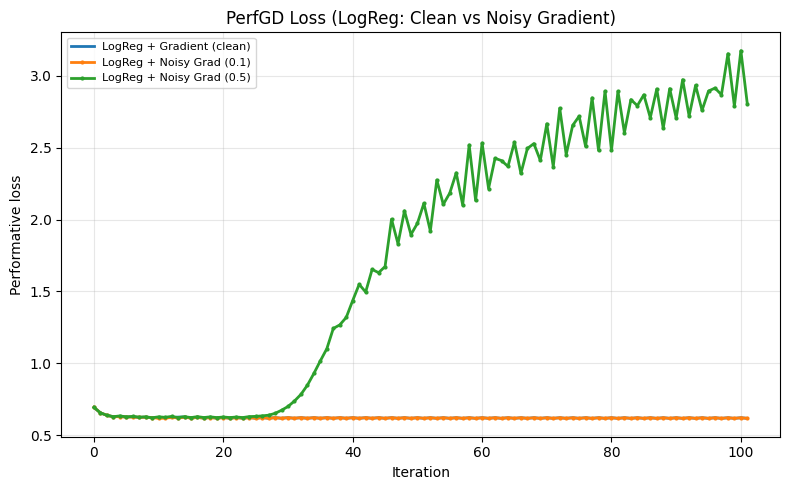

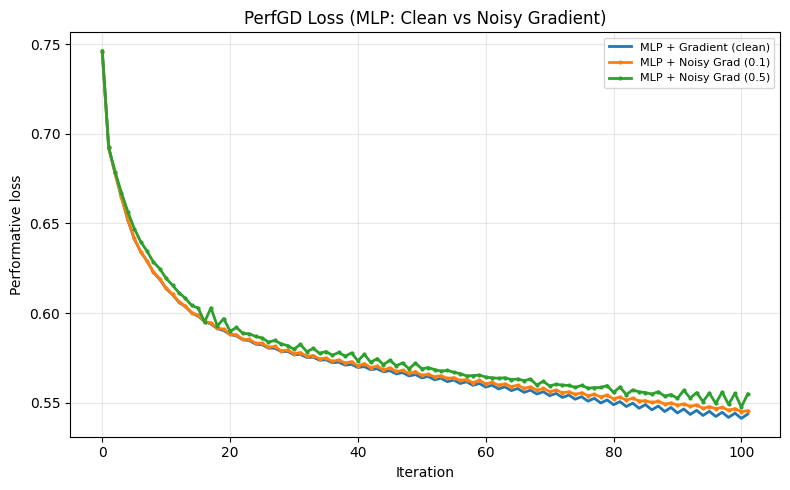

In [167]:
# --- PerfGD Loss: All no-noise experiments ---
no_noise = {k: v for k, v in results.items() if "Noisy" not in k}
logreg_noisy = {k: v for k, v in results.items() if "LogReg" in k and "Noisy" in k}
mlp_noisy = {k: v for k, v in results.items() if "MLP" in k and "Noisy" in k}

fig, ax = plt.subplots(figsize=(8, 5))
for name, res in reversed(list(no_noise.items())):
    ax.plot(res["perfgd_losses"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"Performative loss")
ax.set_title(r"PerfGD Loss (No Noise)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PerfGD Loss: LogReg clean gradient vs noisy ---
fig, ax = plt.subplots(figsize=(8, 5))
if "LogReg + Gradient" in results:
    ax.plot(results["LogReg + Gradient"]["perfgd_losses"], linewidth=2, label="LogReg + Gradient (clean)")
for name, res in logreg_noisy.items():
    ax.plot(res["perfgd_losses"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"Performative loss")
ax.set_title(r"PerfGD Loss (LogReg: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PerfGD Loss: MLP clean gradient vs noisy ---
fig, ax = plt.subplots(figsize=(8, 5))
if "MLP + Gradient" in results:
    ax.plot(results["MLP + Gradient"]["perfgd_losses"], linewidth=2, label="MLP + Gradient (clean)")
for name, res in mlp_noisy.items():
    ax.plot(res["perfgd_losses"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"Performative loss")
ax.set_title(r"PerfGD Loss (MLP: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

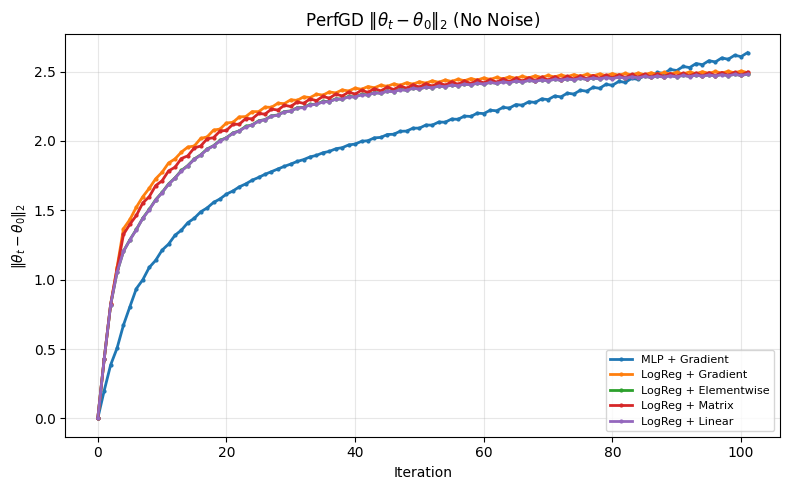

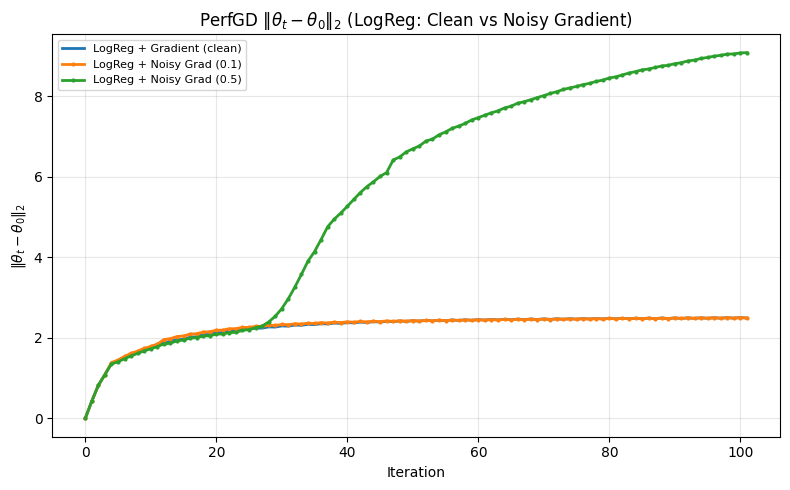

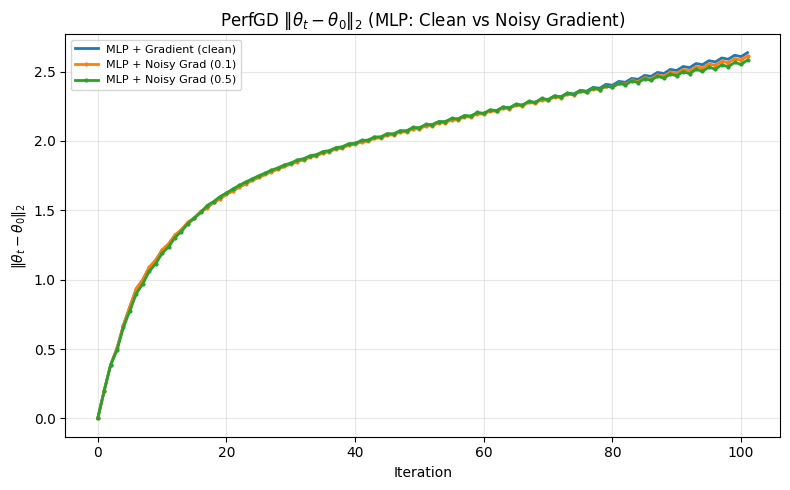

In [168]:
# --- PerfGD $\|\theta_t - \theta_0\|_2$: All no-noise experiments ---
no_noise = {k: v for k, v in results.items() if "Noisy" not in k}
logreg_noisy = {k: v for k, v in results.items() if "LogReg" in k and "Noisy" in k}
mlp_noisy = {k: v for k, v in results.items() if "MLP" in k and "Noisy" in k}

fig, ax = plt.subplots(figsize=(8, 5))
for name, res in reversed(list(no_noise.items())):
    ax.plot(res["perfgd_theta_diffs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
ax.set_title(r"PerfGD $\|\theta_t - \theta_0\|_2$ (No Noise)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PerfGD $\|\theta_t - \theta_0\|_2$: LogReg clean gradient vs noisy ---
fig, ax = plt.subplots(figsize=(8, 5))
if "LogReg + Gradient" in results:
    ax.plot(results["LogReg + Gradient"]["perfgd_theta_diffs"], linewidth=2, label="LogReg + Gradient (clean)")
for name, res in logreg_noisy.items():
    ax.plot(res["perfgd_theta_diffs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
ax.set_title(r"PerfGD $\|\theta_t - \theta_0\|_2$ (LogReg: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PerfGD $\|\theta_t - \theta_0\|_2$: MLP clean gradient vs noisy ---
fig, ax = plt.subplots(figsize=(8, 5))
if "MLP + Gradient" in results:
    ax.plot(results["MLP + Gradient"]["perfgd_theta_diffs"], linewidth=2, label="MLP + Gradient (clean)")
for name, res in mlp_noisy.items():
    ax.plot(res["perfgd_theta_diffs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
ax.set_title(r"PerfGD $\|\theta_t - \theta_0\|_2$ (MLP: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## RGD vs PerfGD per Experiment

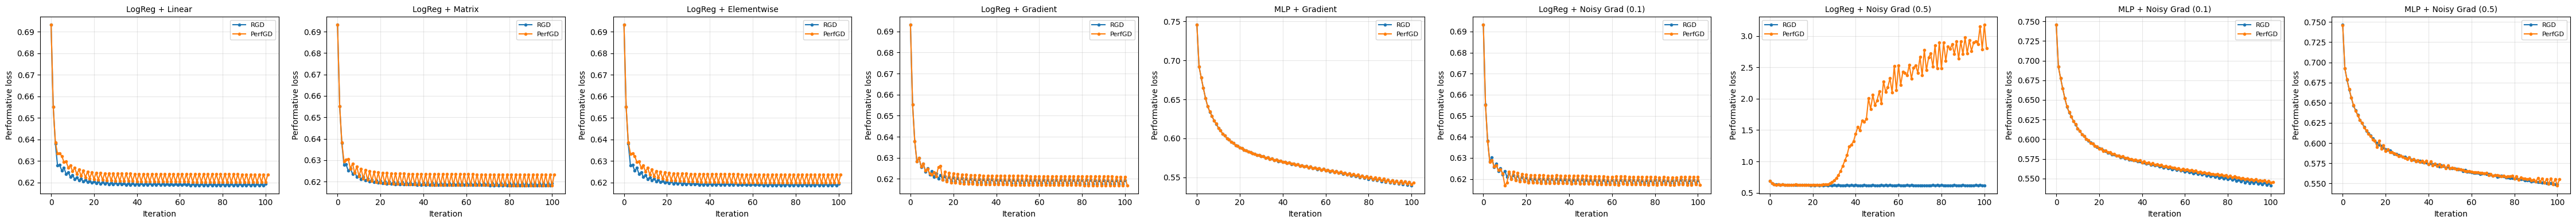

In [169]:
n_exp = len(results)
fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 4))
if n_exp == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    ax.plot(res["rgd_losses"], marker="o", markersize=3, label="RGD", color="tab:blue")
    ax.plot(res["perfgd_losses"], marker="o", markersize=3, label="PerfGD", color="tab:orange")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Performative loss")
    ax.set_title(name, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Table

In [170]:
print(f"{'Experiment':<25} {'RGD loss':>10} {'PerfGD loss':>12} {'RGD acc':>10} {'PerfGD acc':>12} {'RGD diff':>10} {'PerfGD diff':>12}")
print("-" * 95)
for name, res in results.items():
    print(f"{name:<25} {res['rgd_losses'][-1]:>10.4f} {res['perfgd_losses'][-1]:>12.4f} "
          f"{res['rgd_accs'][-1]:>10.4f} {res['perfgd_accs'][-1]:>12.4f} "
          f"{res['rgd_theta_diffs'][-1]:>10.4f} {res['perfgd_theta_diffs'][-1]:>12.4f}")

Experiment                  RGD loss  PerfGD loss    RGD acc   PerfGD acc   RGD diff  PerfGD diff
-----------------------------------------------------------------------------------------------
LogReg + Linear               0.6194       0.6238     0.7037       0.6995     2.5109       2.4812
LogReg + Matrix               0.6192       0.6233     0.7051       0.7062     2.5157       2.4963
LogReg + Elementwise          0.6194       0.6236     0.7037       0.7003     2.5111       2.4839
LogReg + Gradient             0.6194       0.6169     0.7051       0.7105     2.5208       2.4919
MLP + Gradient                0.5398       0.5437     0.7386       0.7314     2.6127       2.6365
LogReg + Noisy Grad (0.1)     0.6193       0.6172     0.7063       0.7097     2.5202       2.4932
LogReg + Noisy Grad (0.5)     0.6207       2.8047     0.7051       0.6321     2.5082       9.0841
MLP + Noisy Grad (0.1)        0.5413       0.5456     0.7374       0.7314     2.6171       2.6125
MLP + Noisy Grad (0.5)

## Classification Accuracy vs Iteration

Accuracy on the strategically-shifted data at each iteration. This is the metric that's comparable across classifiers (logreg vs MLP).

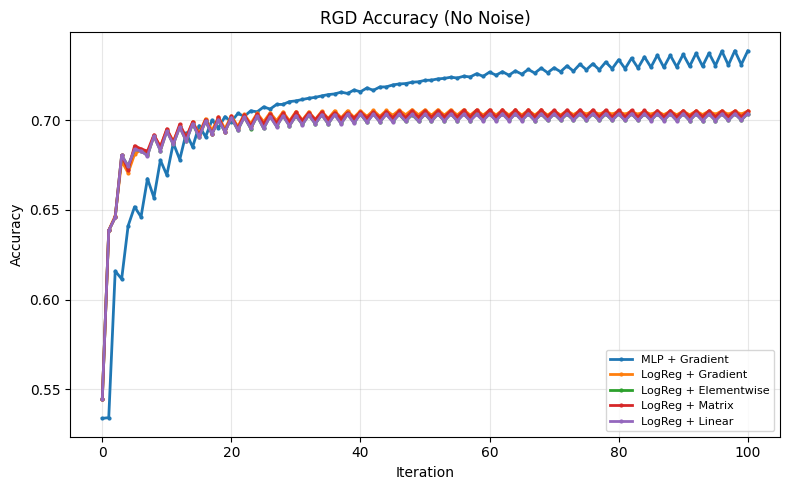

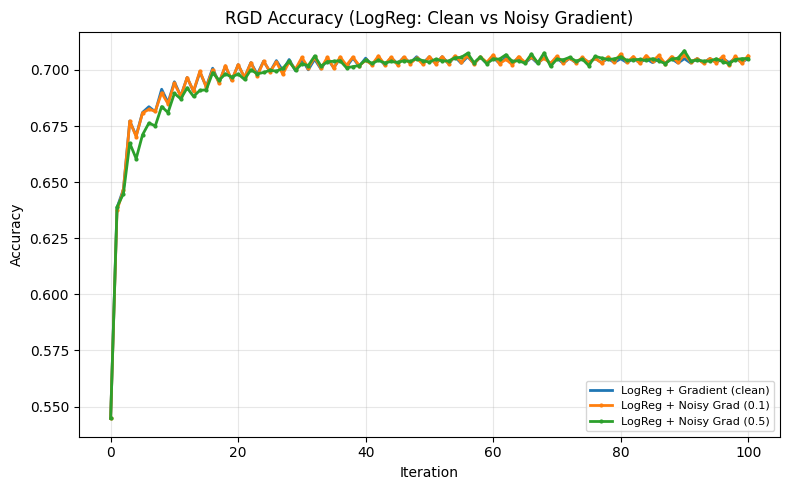

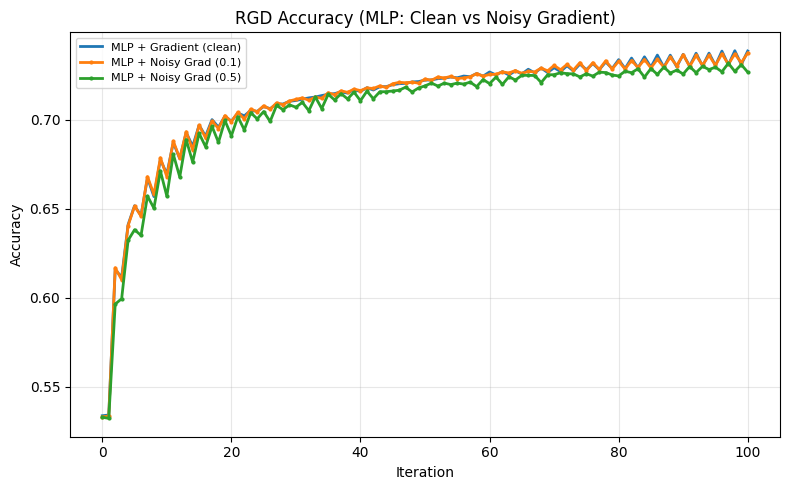

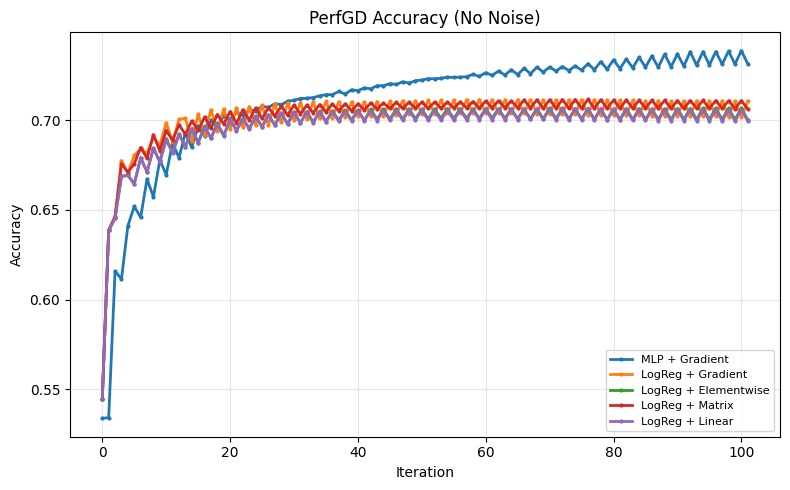

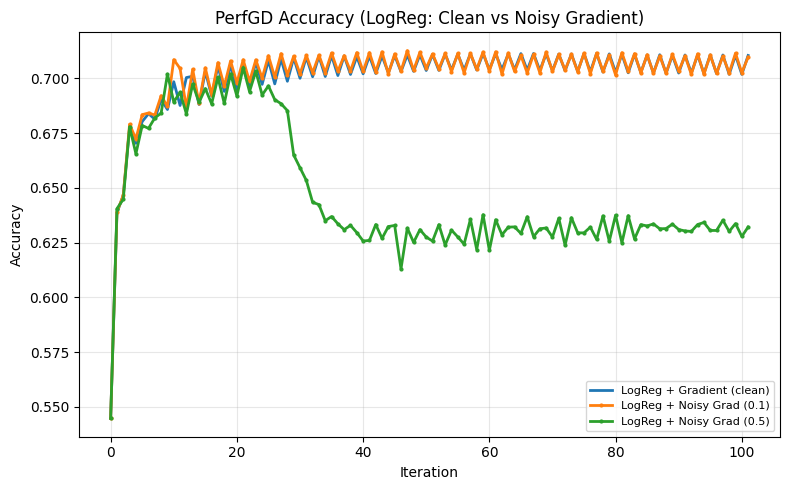

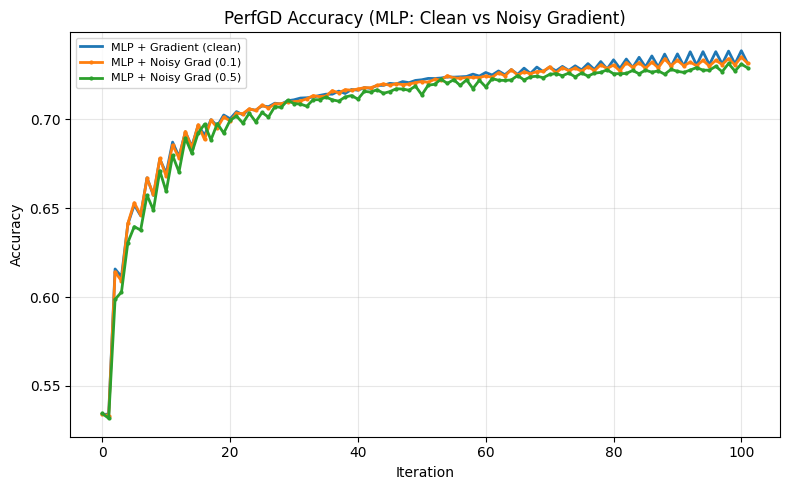

In [171]:
# --- RGD Accuracy ---
no_noise = {k: v for k, v in results.items() if "Noisy" not in k}
logreg_noisy = {k: v for k, v in results.items() if "LogReg" in k and "Noisy" in k}
mlp_noisy = {k: v for k, v in results.items() if "MLP" in k and "Noisy" in k}

fig, ax = plt.subplots(figsize=(8, 5))
for name, res in reversed(list(no_noise.items())):
    ax.plot(res["rgd_accs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.set_title("RGD Accuracy (No Noise)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
if "LogReg + Gradient" in results:
    ax.plot(results["LogReg + Gradient"]["rgd_accs"], linewidth=2, label="LogReg + Gradient (clean)")
for name, res in logreg_noisy.items():
    ax.plot(res["rgd_accs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.set_title("RGD Accuracy (LogReg: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
if "MLP + Gradient" in results:
    ax.plot(results["MLP + Gradient"]["rgd_accs"], linewidth=2, label="MLP + Gradient (clean)")
for name, res in mlp_noisy.items():
    ax.plot(res["rgd_accs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.set_title("RGD Accuracy (MLP: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PerfGD Accuracy ---
fig, ax = plt.subplots(figsize=(8, 5))
for name, res in reversed(list(no_noise.items())):
    ax.plot(res["perfgd_accs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.set_title("PerfGD Accuracy (No Noise)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
if "LogReg + Gradient" in results:
    ax.plot(results["LogReg + Gradient"]["perfgd_accs"], linewidth=2, label="LogReg + Gradient (clean)")
for name, res in logreg_noisy.items():
    ax.plot(res["perfgd_accs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.set_title("PerfGD Accuracy (LogReg: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
if "MLP + Gradient" in results:
    ax.plot(results["MLP + Gradient"]["perfgd_accs"], linewidth=2, label="MLP + Gradient (clean)")
for name, res in mlp_noisy.items():
    ax.plot(res["perfgd_accs"], marker="o", markersize=2, linewidth=2, label=name)
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.set_title("PerfGD Accuracy (MLP: Clean vs Noisy Gradient)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Theta Component Trajectories (LogReg Only)

Plot individual theta components over iterations for all logreg performativity models.
Focuses on the 3 strategic feature weights to check whether different performativity
models lead to meaningfully different classifiers.

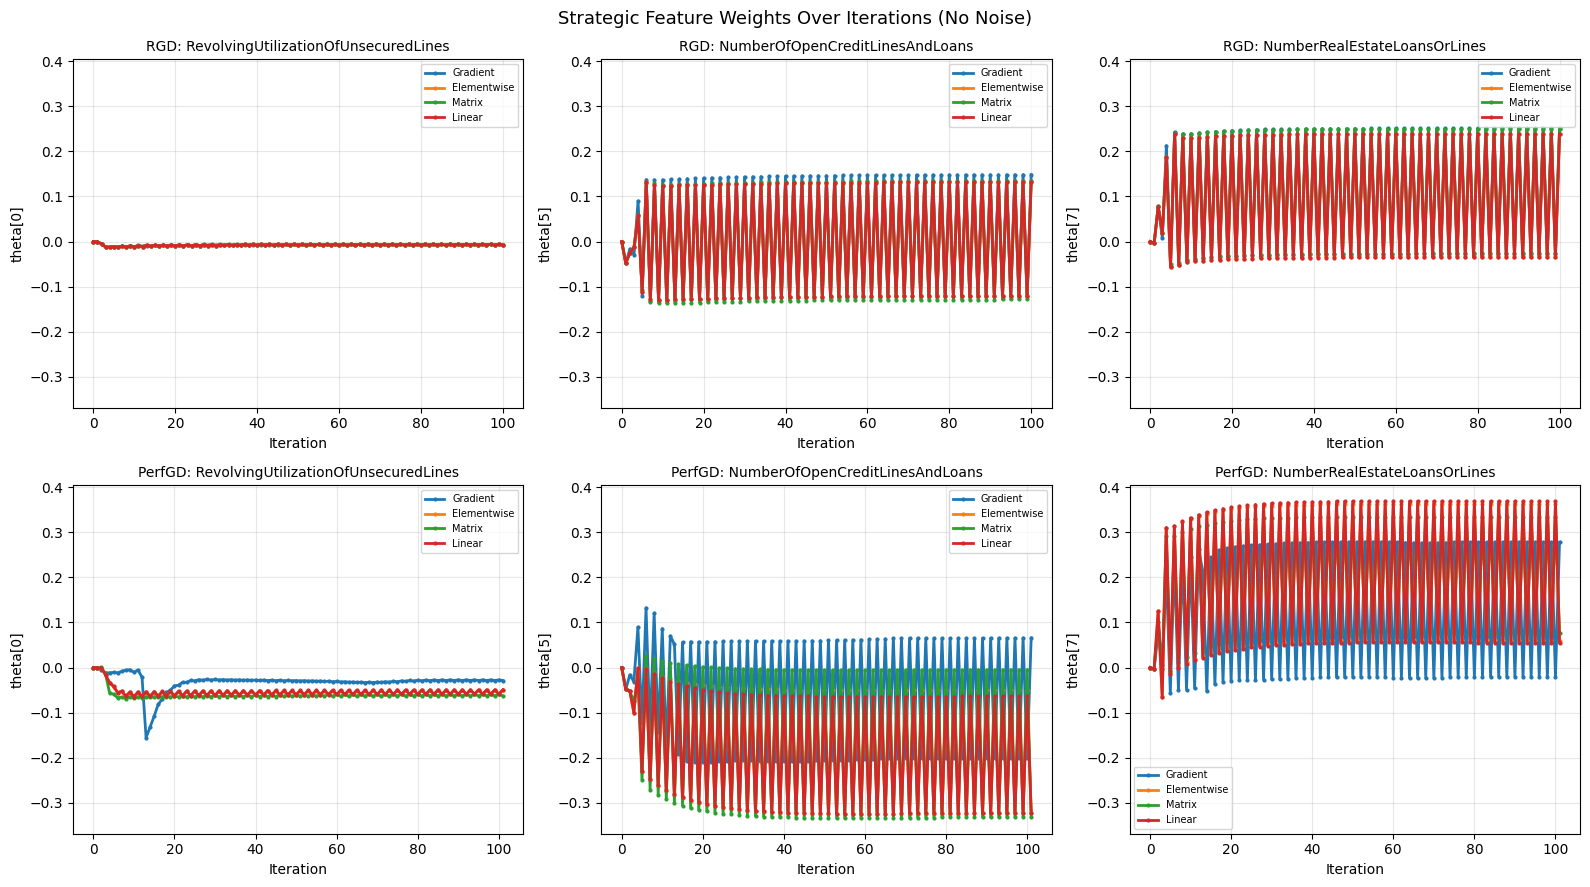

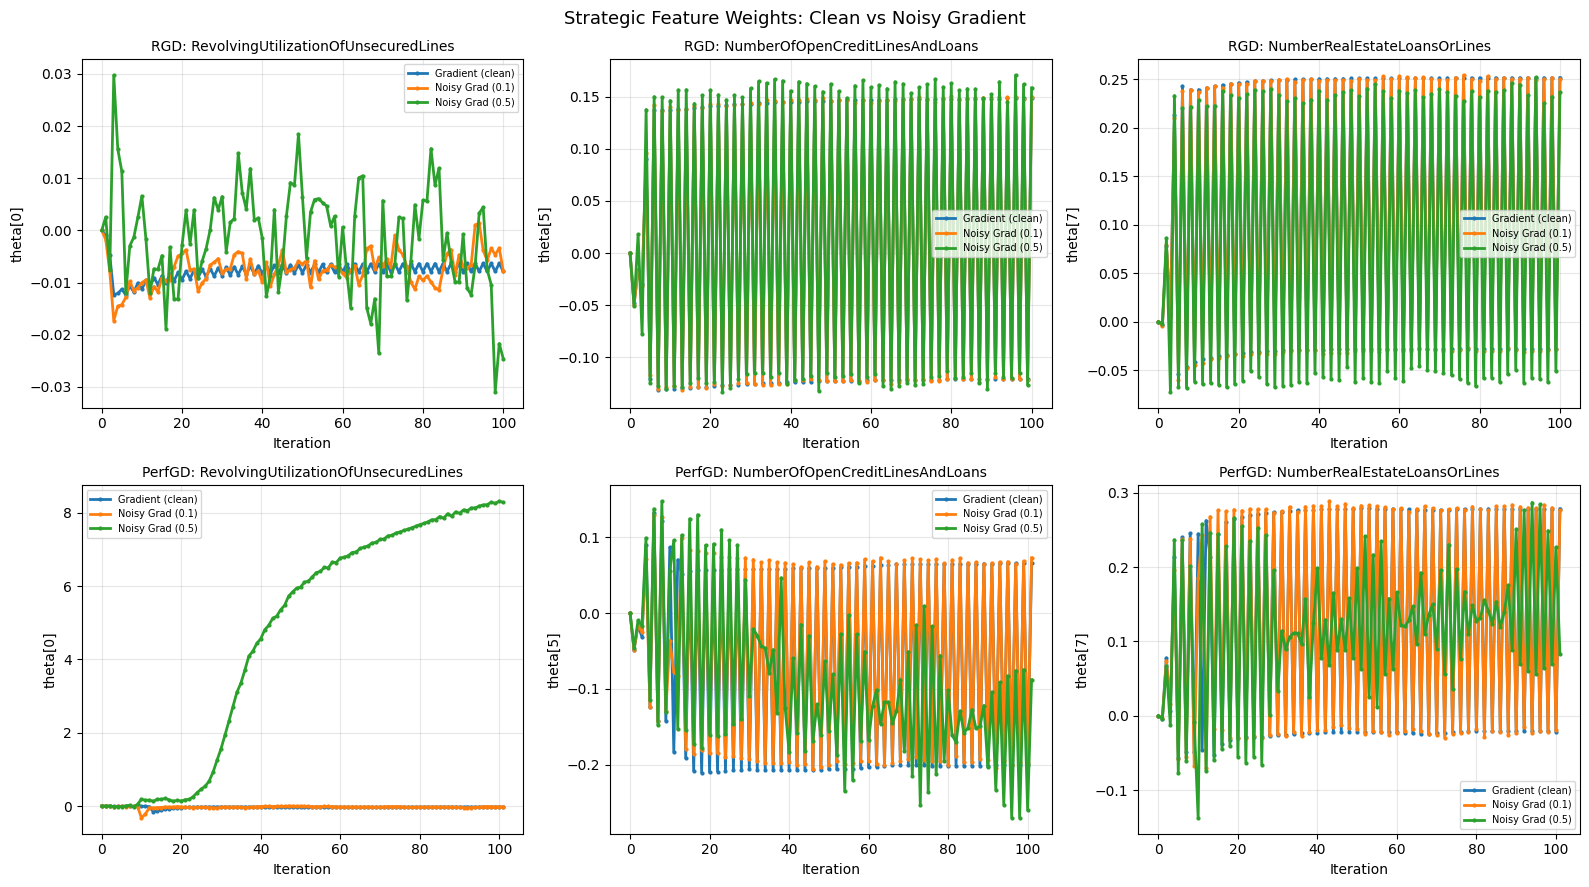

In [172]:
# Feature names for the 11 logreg params (10 features + bias)
feature_names = list(data.columns[1:]) + ["bias"]
strat_feature_names = [feature_names[i] for i in strat_features]

logreg_no_noise = {k: v for k, v in results.items() if v["classifier"] == "logreg" and "Noisy" not in k}
logreg_noisy = {k: v for k, v in results.items() if "LogReg" in k and "Noisy" in k}

# --- Noiseless: Strategic feature weights over iterations ---
# Plot in reverse order so that "Linear" (first in dict) is drawn last (on top)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Compute global y-limits across all subplots
all_vals = []
plot_order = list(logreg_no_noise.items())[::-1]  # reverse so Linear is last (on top)
for algo_label, theta_key in [("RGD", "all_theta_rgd"), ("PerfGD", "all_theta_perfgd")]:
    for feat_idx in strat_features:
        for name, res in plot_order:
            all_vals.extend([t[feat_idx].item() for t in res[theta_key]])
ymin, ymax = min(all_vals), max(all_vals)
pad = (ymax - ymin) * 0.05
ymin -= pad
ymax += pad

for row, (algo_label, theta_key) in enumerate([("RGD", "all_theta_rgd"), ("PerfGD", "all_theta_perfgd")]):
    for col, (feat_idx, feat_name) in enumerate(zip(strat_features, strat_feature_names)):
        ax = axes[row, col]
        for name, res in plot_order:
            label = name.replace("LogReg + ", "")
            vals = [t[feat_idx].item() for t in res[theta_key]]
            ax.plot(vals, marker="o", markersize=2, linewidth=2, label=label)
        ax.set_xlabel("Iteration")
        ax.set_ylabel(f"theta[{feat_idx}]")
        ax.set_title(f"{algo_label}: {feat_name}", fontsize=10)
        ax.set_ylim(ymin, ymax)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle("Strategic Feature Weights Over Iterations (No Noise)", fontsize=13)
plt.tight_layout()
plt.show()

# --- Noisy: Clean gradient vs noisy gradient for strategic features ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

gradient_and_noisy = {}
if "LogReg + Gradient" in results:
    gradient_and_noisy["Gradient (clean)"] = results["LogReg + Gradient"]
for k, v in logreg_noisy.items():
    gradient_and_noisy[k.replace("LogReg + ", "")] = v

for row, (algo_label, theta_key) in enumerate([("RGD", "all_theta_rgd"), ("PerfGD", "all_theta_perfgd")]):
    for col, (feat_idx, feat_name) in enumerate(zip(strat_features, strat_feature_names)):
        ax = axes[row, col]
        for name, res in gradient_and_noisy.items():
            vals = [t[feat_idx].item() for t in res[theta_key]]
            ax.plot(vals, marker="o", markersize=2, linewidth=2, label=name)
        ax.set_xlabel("Iteration")
        ax.set_ylabel(f"theta[{feat_idx}]")
        ax.set_title(f"{algo_label}: {feat_name}", fontsize=10)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.suptitle("Strategic Feature Weights: Clean vs Noisy Gradient", fontsize=13)
plt.tight_layout()
plt.show()

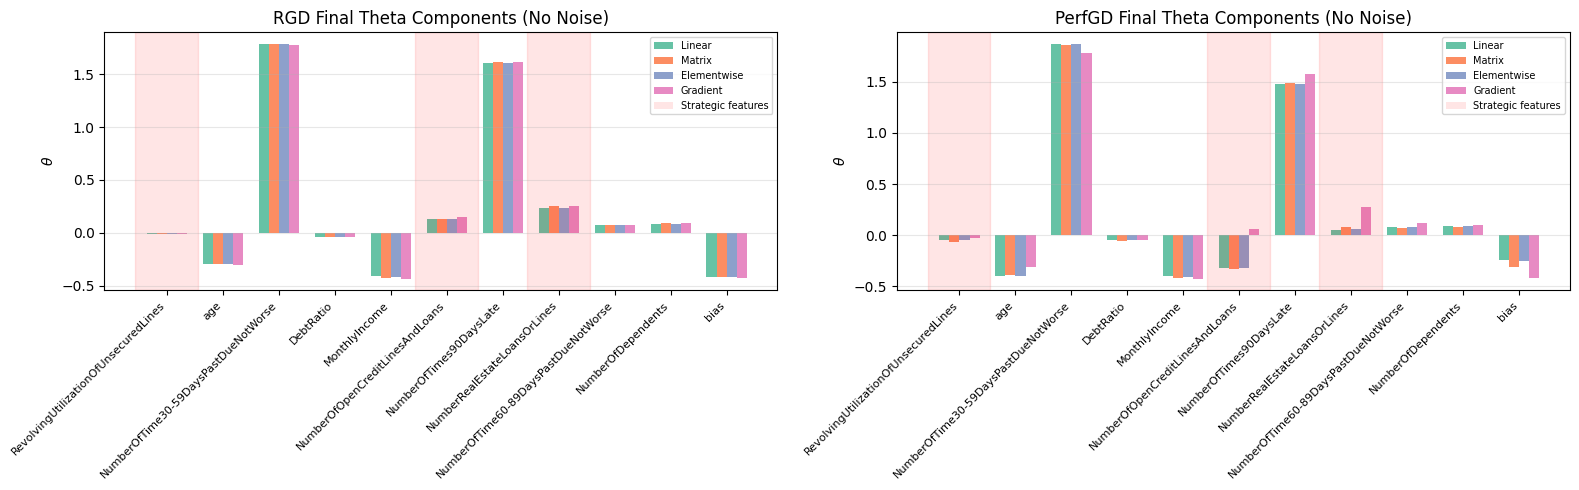

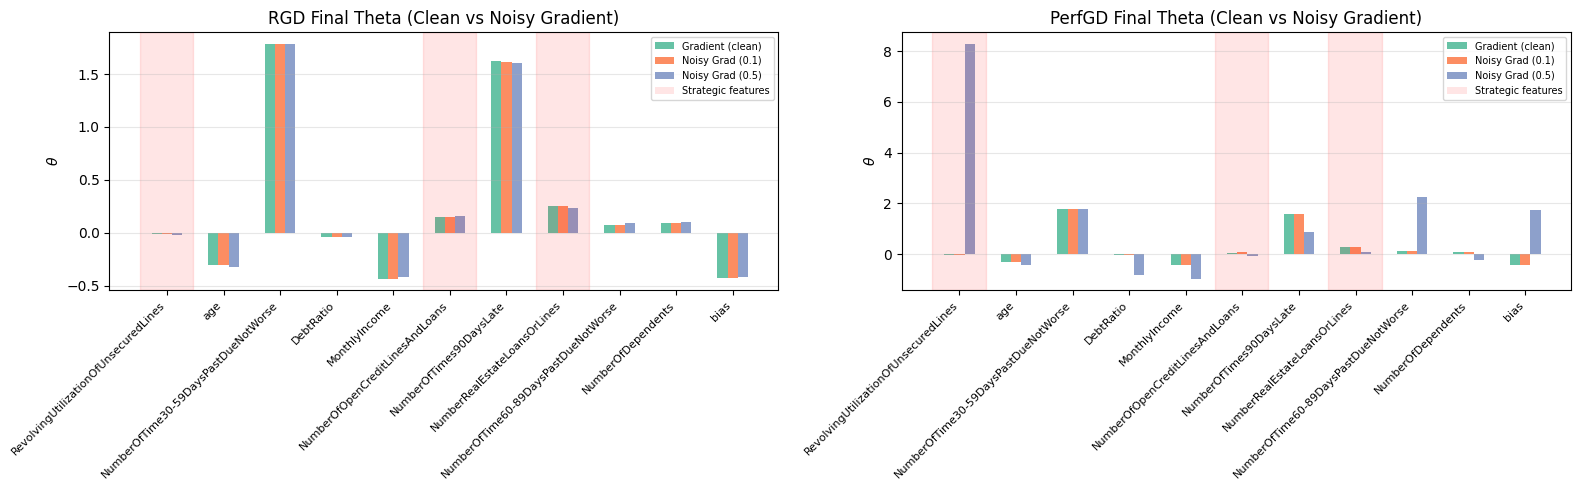

In [173]:
# --- Noiseless: All 11 theta components final values ---
from matplotlib.patches import Patch

logreg_no_noise = {k: v for k, v in results.items() if v["classifier"] == "logreg" and "Noisy" not in k}
logreg_noisy = {k: v for k, v in results.items() if "LogReg" in k and "Noisy" in k}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

x_pos = np.arange(len(feature_names))
width = 0.18
colors = plt.cm.Set2.colors

for i, (name, res) in enumerate(logreg_no_noise.items()):
    label = name.replace("LogReg + ", "")
    final_rgd = res["all_theta_rgd"][-1].numpy()
    final_pgd = res["all_theta_perfgd"][-1].numpy()
    ax1.bar(x_pos + i * width, final_rgd, width, label=label, color=colors[i])
    ax2.bar(x_pos + i * width, final_pgd, width, label=label, color=colors[i])

for ax, title in [(ax1, "RGD"), (ax2, "PerfGD")]:
    for idx in strat_features:
        ax.axvspan(idx - 0.3, idx + len(logreg_no_noise) * width + 0.1, alpha=0.1, color="red")
    ax.set_xticks(x_pos + width * (len(logreg_no_noise) - 1) / 2)
    ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(r"$\theta$")
    ax.set_title(f"{title} Final Theta Components (No Noise)")
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Patch(facecolor="red", alpha=0.1, label="Strategic features"))
    labels.append("Strategic features")
    ax.legend(handles=handles, labels=labels, fontsize=7)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# --- Noisy: Clean gradient vs noisy gradient final theta ---
gradient_and_noisy = {}
if "LogReg + Gradient" in results:
    gradient_and_noisy["Gradient (clean)"] = results["LogReg + Gradient"]
for k, v in logreg_noisy.items():
    gradient_and_noisy[k.replace("LogReg + ", "")] = v

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for i, (name, res) in enumerate(gradient_and_noisy.items()):
    final_rgd = res["all_theta_rgd"][-1].numpy()
    final_pgd = res["all_theta_perfgd"][-1].numpy()
    ax1.bar(x_pos + i * width, final_rgd, width, label=name, color=colors[i])
    ax2.bar(x_pos + i * width, final_pgd, width, label=name, color=colors[i])

for ax, title in [(ax1, "RGD"), (ax2, "PerfGD")]:
    for idx in strat_features:
        ax.axvspan(idx - 0.3, idx + len(gradient_and_noisy) * width + 0.1, alpha=0.1, color="red")
    ax.set_xticks(x_pos + width * (len(gradient_and_noisy) - 1) / 2)
    ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(r"$\theta$")
    ax.set_title(f"{title} Final Theta (Clean vs Noisy Gradient)")
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Patch(facecolor="red", alpha=0.1, label="Strategic features"))
    labels.append("Strategic features")
    ax.legend(handles=handles, labels=labels, fontsize=7)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [174]:
# --- Max pairwise difference in final theta across performativity models ---
logreg_no_noise = {k: v for k, v in results.items() if v["classifier"] == "logreg" and "Noisy" not in k}
logreg_names = list(logreg_no_noise.keys())
print("Pairwise L2 distance between final RGD thetas:")
for i in range(len(logreg_names)):
    for j in range(i + 1, len(logreg_names)):
        diff_rgd = (logreg_no_noise[logreg_names[i]]["rgd_theta"] - logreg_no_noise[logreg_names[j]]["rgd_theta"]).norm().item()
        diff_pgd = (logreg_no_noise[logreg_names[i]]["perfgd_theta"] - logreg_no_noise[logreg_names[j]]["perfgd_theta"]).norm().item()
        ni = logreg_names[i].replace("LogReg + ", "")
        nj = logreg_names[j].replace("LogReg + ", "")
        print(f"  {ni:>15s} vs {nj:<15s}  RGD: {diff_rgd:.6f}   PerfGD: {diff_pgd:.6f}")

print("\nStrategic feature weights only (final RGD):")
for name, res in logreg_no_noise.items():
    vals = [res["rgd_theta"][i].item() for i in strat_features]
    label = name.replace("LogReg + ", "")
    print(f"  {label:<15s}  " + "  ".join(f"{v:+.4f}" for v in vals))

Pairwise L2 distance between final RGD thetas:
           Linear vs Matrix           RGD: 0.017592   PerfGD: 0.079394
           Linear vs Elementwise      RGD: 0.000634   PerfGD: 0.014081
           Linear vs Gradient         RGD: 0.033519   PerfGD: 0.504990
           Matrix vs Elementwise      RGD: 0.016984   PerfGD: 0.066944
           Matrix vs Gradient         RGD: 0.022059   PerfGD: 0.480807
      Elementwise vs Gradient         RGD: 0.032943   PerfGD: 0.498765

Strategic feature weights only (final RGD):
  Linear           -0.0081  +0.1322  +0.2387
  Matrix           -0.0081  +0.1348  +0.2498
  Elementwise      -0.0081  +0.1324  +0.2391
  Gradient         -0.0079  +0.1485  +0.2515


## MLP Convergence

Run MLP + Gradient for 500 iterations to check if loss stabilizes or keeps dropping.
Compare accuracy to logreg to determine if MLP is just more expressive or overfitting to the strategic shift.

In [175]:
# Run MLP + Gradient for 500 iterations
mlp_max_iter = 500

mu_f, sigma, D_theta_mlp, loss_fn_mlp, theta_0_mlp, grad2_est_mlp, f_hat_mlp = \
    setup_strategic_classification(
        X_base=X_full, Y_base=Y_full, strat_features=strat_features.tolist(),
        alpha=alpha_strat, lam=lam, classifier="mlp", performativity="gradient",
        perfGD=True, hidden_dims=MLP_HIDDEN_DIMS,
    )

d = X_full.shape[1] - 1

print(f"Running MLP + Gradient for {mlp_max_iter} iterations...")
theta_mlp_long, all_theta_mlp_long, all_losses_mlp_long = RGD(
    D_theta=D_theta_mlp, loss=loss_fn_mlp, theta_0=theta_0_mlp.clone(),
    n=n, eta=eta_mlp, max_iter=mlp_max_iter, proj_theta=proj_theta, return_losses=True,
)

print(f"Running MLP + Gradient PerfGD for {mlp_max_iter} iterations...")
theta_mlp_long_pgd, all_theta_mlp_long_pgd, all_losses_mlp_long_pgd = PerfGD(
    f_hat=f_hat_mlp, grad2_est=grad2_est_mlp, D_theta=D_theta_mlp, loss=loss_fn_mlp,
    theta_0=theta_0_mlp.clone(), n=n, eta=eta_mlp, max_iter=mlp_max_iter,
    proj_theta=proj_theta, return_losses=True,
)

# Compute accuracies (subsample every 10 iterations to save time)
print("Computing accuracies...")
step = 10
mlp_rgd_accs_long = [compute_accuracy(all_theta_mlp_long[i], D_theta_mlp, "mlp", MLP_HIDDEN_DIMS, d, n)
                      for i in range(0, len(all_theta_mlp_long), step)]
mlp_pgd_accs_long = [compute_accuracy(all_theta_mlp_long_pgd[i], D_theta_mlp, "mlp", MLP_HIDDEN_DIMS, d, n)
                      for i in range(0, len(all_theta_mlp_long_pgd), step)]
acc_iters = list(range(0, len(all_theta_mlp_long), step))

# Get logreg baselines for comparison
logreg_final_rgd_acc = results["LogReg + Linear"]["rgd_accs"][-1]
logreg_final_pgd_acc = results["LogReg + Linear"]["perfgd_accs"][-1]

print(f"MLP RGD  final loss: {all_losses_mlp_long[-1]:.4f}, acc: {mlp_rgd_accs_long[-1]:.4f}")
print(f"MLP PerfGD final loss: {all_losses_mlp_long_pgd[-1]:.4f}, acc: {mlp_pgd_accs_long[-1]:.4f}")
print(f"LogReg Linear RGD final acc: {logreg_final_rgd_acc:.4f}")
print(f"LogReg Linear PerfGD final acc: {logreg_final_pgd_acc:.4f}")

Running MLP + Gradient for 500 iterations...
Running MLP + Gradient PerfGD for 500 iterations...
Computing accuracies...
MLP RGD  final loss: 0.5322, acc: 0.7471
MLP PerfGD final loss: 0.5299, acc: 0.7426
LogReg Linear RGD final acc: 0.7037
LogReg Linear PerfGD final acc: 0.6995


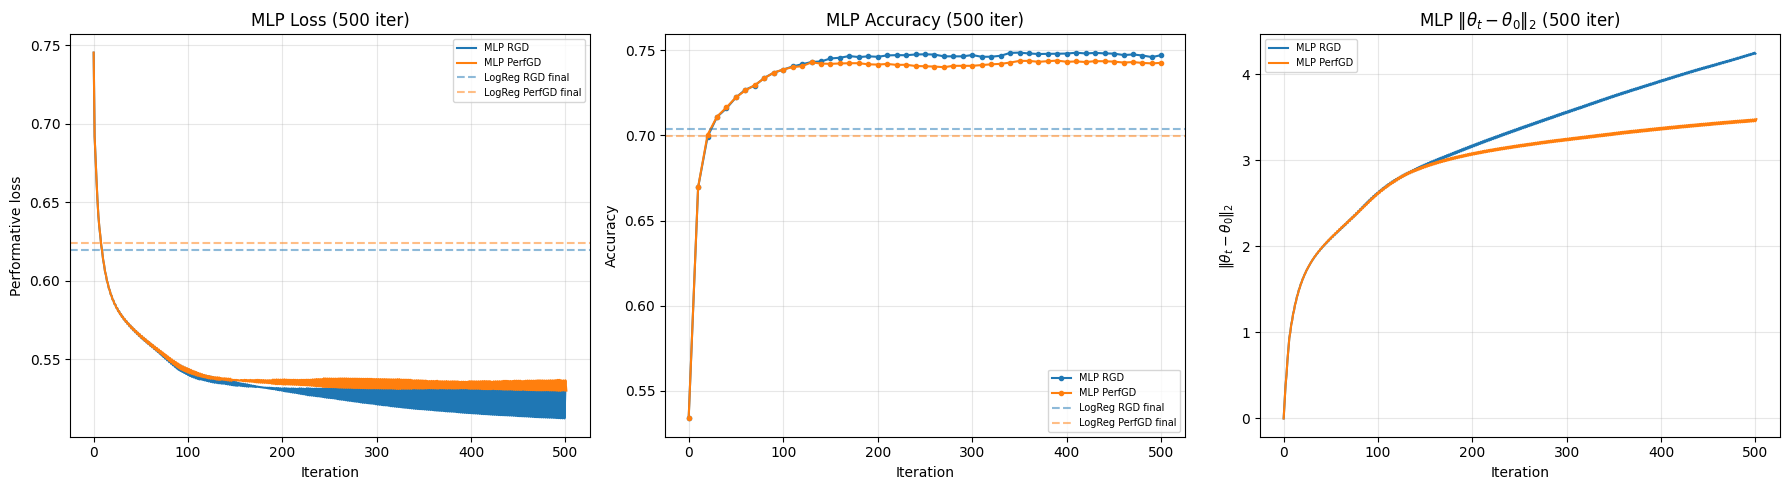

In [176]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(all_losses_mlp_long, label="MLP RGD", color="tab:blue")
axes[0].plot(all_losses_mlp_long_pgd, label="MLP PerfGD", color="tab:orange")
axes[0].axhline(results["LogReg + Linear"]["rgd_losses"][-1], color="tab:blue", linestyle="--", alpha=0.5, label="LogReg RGD final")
axes[0].axhline(results["LogReg + Linear"]["perfgd_losses"][-1], color="tab:orange", linestyle="--", alpha=0.5, label="LogReg PerfGD final")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Performative loss")
axes[0].set_title("MLP Loss (500 iter)")
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(acc_iters, mlp_rgd_accs_long, marker="o", markersize=3, label="MLP RGD", color="tab:blue")
axes[1].plot(acc_iters, mlp_pgd_accs_long, marker="o", markersize=3, label="MLP PerfGD", color="tab:orange")
axes[1].axhline(logreg_final_rgd_acc, color="tab:blue", linestyle="--", alpha=0.5, label="LogReg RGD final")
axes[1].axhline(logreg_final_pgd_acc, color="tab:orange", linestyle="--", alpha=0.5, label="LogReg PerfGD final")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("MLP Accuracy (500 iter)")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

# Parameter norm change
mlp_theta_diffs = [(t - all_theta_mlp_long[0]).norm().item() for t in all_theta_mlp_long]
mlp_theta_diffs_pgd = [(t - all_theta_mlp_long_pgd[0]).norm().item() for t in all_theta_mlp_long_pgd]
axes[2].plot(mlp_theta_diffs, label="MLP RGD", color="tab:blue")
axes[2].plot(mlp_theta_diffs_pgd, label="MLP PerfGD", color="tab:orange")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel(r"$\|\theta_t - \theta_0\|_2$")
axes[2].set_title(r"MLP $\|\theta_t - \theta_0\|_2$ (500 iter)")
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()